In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('C:/Users/mlula/Downloads/MRDM/bank+marketing classification/bank/bank-full.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [47]:
##Simulate Multi-Relational Tables

In [51]:
# CLIENT TABLE
client = df[['age', 'job', 'marital', 'education']].copy()
client['client_id'] = client.index

# FINANCIAL TABLE
financial = df[['balance', 'housing', 'loan']].copy()
financial['client_id'] = financial.index

# CAMPAIGN TABLE
campaign = df[['contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']].copy()
campaign['client_id'] = campaign.index

# TARGET TABLE
target = df[['y']].copy()
target['client_id'] = target.index

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [53]:
# Join all tables
mrdm_df = client.merge(financial, on="client_id")
mrdm_df = mrdm_df.merge(campaign, on="client_id")
mrdm_df = mrdm_df.merge(target, on="client_id")

mrdm_df

,age,job,marital,education,client_id,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,261,1,-1,0,3,0
1,44,9,2,1,1,29,1,0,2,151,1,-1,0,3,0
2,33,2,1,1,2,2,1,1,2,76,1,-1,0,3,0
3,47,1,1,3,3,1506,1,0,2,92,1,-1,0,3,0
4,33,11,2,3,4,1,0,0,2,198,1,-1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,2,45206,825,0,0,0,977,3,-1,0,3,1
45207,71,5,0,0,45207,1729,0,0,0,456,2,-1,0,3,1
45208,72,5,1,1,45208,5715,0,0,0,1127,5,184,3,2,1
45209,57,1,1,1,45209,668,0,0,1,508,4,-1,0,3,0


In [54]:
##Convert categorical → numerical

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in mrdm_df.columns:
    if mrdm_df[col].dtype == 'object':
        mrdm_df[col] = le.fit_transform(mrdm_df[col])

In [56]:
##Features & Target

In [57]:
X = mrdm_df.drop(['y', 'client_id'], axis=1)
y = mrdm_df['y']

In [58]:
##Train Test Split

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
##Train Model (Classification)

In [61]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8966051089240297
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.62      0.37      0.47      1091

    accuracy                           0.90      9043
   macro avg       0.77      0.67      0.70      9043
weighted avg       0.88      0.90      0.89      9043



In [63]:
##“We simulated a multi-relational environment by decomposing the dataset into logical tables and re-integrating them for classification.”

In [64]:
##RULE-BASED CLASSIFICATION If-Then Rules

In [65]:
def rule_based_classifier(row):
    if row['duration'] > 300 and row['balance'] > 1000:
        return 1
    elif row['housing'] == 1 and row['loan'] == 1:
        return 0
    else:
        return 0

y_pred_rule = X_test.apply(rule_based_classifier, axis=1)

from sklearn.metrics import accuracy_score

print("=== RULE-BASED CLASSIFICATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rule))
print("\nSample Predictions:")
print(y_pred_rule.head())

=== RULE-BASED CLASSIFICATION ===
Accuracy: 0.8479486895941613

Sample Predictions:
3776     0
9928     0
33409    0
31885    1
15738    0
dtype: int64


In [66]:
print("=== TUPLE ID PROPAGATION ===")

# Show sample client IDs
print("Client Table:")
print(client)

print("\nFinancial Table (linked via client_id):")
print(financial)

print("\nCampaign Table (linked via client_id):")
print(campaign)

=== TUPLE ID PROPAGATION ===
Client Table:
       age  job  marital  education  client_id
0       58    4        1          2          0
1       44    9        2          1          1
2       33    2        1          1          2
3       47    1        1          3          3
4       33   11        2          3          4
...    ...  ...      ...        ...        ...
45206   51    9        1          2      45206
45207   71    5        0          0      45207
45208   72    5        1          1      45208
45209   57    1        1          1      45209
45210   37    2        1          1      45210

[45211 rows x 5 columns]

Financial Table (linked via client_id):
       balance  housing  loan  client_id
0         2143        1     0          0
1           29        1     0          1
2            2        1     1          2
3         1506        1     0          3
4            1        0     0          4
...        ...      ...   ...        ...
45206      825        0     0      4520

In [67]:
#RULE GENERATION OUTPUT (Decision Tree)

In [68]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)

rules = export_text(tree, feature_names=list(X.columns))

print("=== GENERATED RULES ===")
print(rules)

=== GENERATED RULES ===
|--- duration <= 510.50
|   |--- pdays <= 9.50
|   |   |--- age <= 60.50
|   |   |   |--- class: 0
|   |   |--- age >  60.50
|   |   |   |--- class: 0
|   |--- pdays >  9.50
|   |   |--- poutcome <= 1.50
|   |   |   |--- class: 0
|   |   |--- poutcome >  1.50
|   |   |   |--- class: 1
|--- duration >  510.50
|   |--- duration <= 835.50
|   |   |--- contact <= 1.50
|   |   |   |--- class: 0
|   |   |--- contact >  1.50
|   |   |   |--- class: 0
|   |--- duration >  835.50
|   |   |--- contact <= 1.50
|   |   |   |--- class: 1
|   |   |--- contact >  1.50
|   |   |   |--- class: 0



In [69]:
##NEGATIVE TUPLE SAMPLING OUTPUT

In [70]:
print("=== BEFORE SAMPLING ===")
print(mrdm_df['y'].value_counts())

# Sampling
positive = mrdm_df[mrdm_df['y'] == 1]
negative = mrdm_df[mrdm_df['y'] == 0]

negative_sampled = negative.sample(n=len(positive), random_state=42)
balanced_df = pd.concat([positive, negative_sampled])

print("\n=== AFTER SAMPLING ===")
print(balanced_df['y'].value_counts())

=== BEFORE SAMPLING ===
y
0    39922
1     5289
Name: count, dtype: int64

=== AFTER SAMPLING ===
y
1    5289
0    5289
Name: count, dtype: int64


In [71]:
##FINAL MODEL OUTPUT (AFTER ALL TECHNIQUES)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

X = balanced_df.drop(['y', 'client_id'], axis=1)
y = balanced_df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== FINAL MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))

=== FINAL MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1038
           1       0.80      0.79      0.80      1078

    accuracy                           0.79      2116
   macro avg       0.79      0.79      0.79      2116
weighted avg       0.79      0.79      0.79      2116



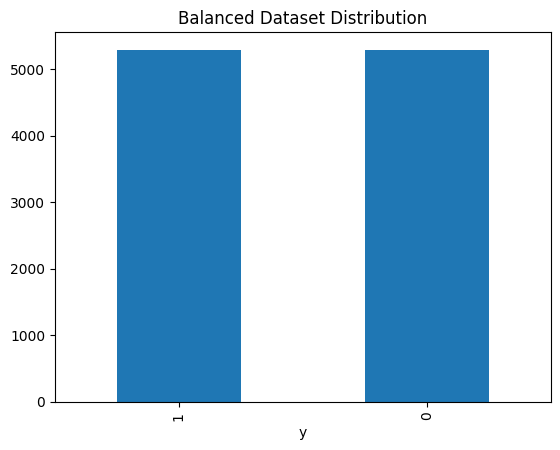

In [27]:
balanced_df['y'].value_counts().plot(kind='bar')
plt.title("Balanced Dataset Distribution")
plt.show()